# **Project: Unsupervised Fraud Detection in MOT Datasets**

**Objective:** To identify fraud (subtle odometer manipulation) within UK MOT records using behavioral anomaly detection.

* Unsupervised Models: Comparative analysis of Isolation Forest, One-Class SVM, Local Outlier Factor, and Elliptic Envelope.

* Scientific Validation: Model performance was evaluated against injected synthetic anomalies to measure Precision (false alarm rate) and Recall (detection rate).

**Goal:** Determine which algorithm most effectively identifies subtle fraud patterns

**Dataset Description:** DVSA MOT Test Records
Source: Official UK Government (DVSA) MOT testing data.

Data Scope:

 * Core Features: Includes vehicle_id, test_date, and test_mileage.

 * Contains vehicle specifics such as make, model, and fuel_type,.

 * The longitudinal nature of the data (multiple tests over years for the same vehicle) allows for the creation of time-series behavioral features.

 # Data Loading & Environment Setup



*   Mounting Drive





In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


* Importing libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

* loading Dataset

In [3]:
import pandas as pd
output_path = "/content/drive/MyDrive/MOT/mot_2018_2024_10percent_by_vehicle.csv.gz"
df1 = pd.read_csv(output_path, low_memory=False)


In [4]:
df1.head()

,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,colour,fuel_type,cylinder_capacity,first_use_date,mot_year,completed_date
0,1886686693,133782560,2018-01-01,4,NT,P,93737.0,B,ROVER,75,BLUE,DI,1951.0,2003-11-27,2018,NaN
1,649880599,1359750734,2018-01-01,4,NT,P,87226.0,B,MERCEDES-BENZ,B,BLUE,DI,1991.0,2007-06-28,2018,NaN
2,393989683,1145230428,2018-01-01,4,NT,P,112663.0,LU,BMW,3 SERIES,RED,PE,2497.0,2006-07-24,2018,NaN
3,1967504823,1017819996,2018-01-01,4,NT,P,174561.0,PR,BMW,530,GREY,DI,2926.0,2003-03-31,2018,NaN
4,180747253,1161058062,2018-01-01,4,NT,P,39556.0,B,MAZDA,2,RED,PE,1349.0,2009-10-16,2018,NaN


# Data Sampling

* "performing unique vehicle-id sampling to create a manageable subset for behavioral analysis."

In [5]:
np.random.seed(42)

vehicle_ids = df1["vehicle_id"].unique()
sample_ids = np.random.choice(
    vehicle_ids,
    size=40000,
    replace=False
)

In [6]:
df = df1[df1["vehicle_id"].isin(sample_ids)]

In [7]:
df.head()

,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,colour,fuel_type,cylinder_capacity,first_use_date,mot_year,completed_date
43,1855334799,1347905358,2018-01-01,4,NT,P,135638.0,CB,MITSUBISHI,SHOGUN,BLUE,DI,2477.0,1992-12-31,2018,NaN
93,241908029,1130278842,2018-01-02,4,RT,P,77898.0,HP,VAUXHALL,ASTRA,RED,PE,1364.0,2008-12-29,2018,NaN
105,726418861,945956584,2018-01-02,4,NT,P,132811.0,CV,HONDA,CIVIC,BLUE,DI,2204.0,2008-03-28,2018,NaN
175,1384061519,336571628,2018-01-02,4,NT,F,203494.0,GU,BMW,3 SERIES,SILVER,DI,1995.0,2002-01-04,2018,NaN
181,695066967,1427536739,2018-01-02,4,NT,P,100075.0,LE,AUDI,A4,SILVER,DI,1968.0,2014-06-24,2018,NaN


Sorting the dataset by vehicle id and test dates

In [8]:
df = df.sort_values(
    ["vehicle_id", "test_date"]
)
df = df.reset_index(drop=True)

Poisoning the dataset to create a testing dataset for models validation.

*   here we will pick randomly 600 vehicles and add 5000 miles in there previous year MOT mileage reading to create a fraud dataset later we will label them as fraud and use them in our testing datset.
*   here we will create a coloumn synthetic label where we will name the poisoned data as clocked commuters and remaining dataset we will name them as normal.




In [9]:
# # 1. Get unique vehicles
# unique_cars = df['vehicle_id'].unique()

# # 2. Select 600 vehicles to turn into "Suspects"
# np.random.seed(42)
# suspect_vids = np.random.choice(unique_cars, size=600, replace=False)

# # --- NEW: Split suspects into two different fraud types ---
# group_rollback = suspect_vids[:0]
# group_commuter = suspect_vids[0:]

# # Mark EVERYTHING as Normal first
# df['synthetic_label'] = 'Normal'

# # 3. Sort to ensure we are modifying the LATEST record
# df = df.sort_values(['vehicle_id', 'test_date'])

# # 4. Inject Synthetic Fraud
# for vid in suspect_vids:
#     idx_list = df[df['vehicle_id'] == vid].index
#     if len(idx_list) < 2: continue

#     last_idx = idx_list[-1]
#     prev_idx = idx_list[-2]
#     prev_mileage = df.at[prev_idx, 'test_mileage']

#     # --- PERSONA 1: The Rollback (-10,000 miles) ---
#     if vid in group_rollback:
#         df.at[last_idx, 'test_mileage'] = max(0, prev_mileage - 10000)
#         df.at[last_idx, 'synthetic_label'] = 'Rollback'

#     # --- PERSONA 2: The Clocked Commuter (Subtle +500 miles) ---
#     elif vid in group_commuter:
#         # We give them a tiny increase so it's not negative,
#         # but it will crash their 'usage_trend_shift'
#         df.at[last_idx, 'test_mileage'] = prev_mileage + 5000
#         df.at[last_idx, 'synthetic_label'] = 'Clocked_Commuter'

In [10]:
# 1. Get unique vehicles
unique_cars = df['vehicle_id'].unique()

# 2. Select 600 vehicles to turn into "Clocked Commuters"
np.random.seed(42)
suspect_vids = np.random.choice(unique_cars, size=600, replace=False)

# 3. Mark everything as Normal first
df['synthetic_label'] = 'Normal'

# 4. Sort to ensure we are modifying the LATEST record
df = df.sort_values(['vehicle_id', 'test_date'])

# 5. Inject Synthetic Fraud (Clocked Commuter Persona)
for vid in suspect_vids:
    # Get all indices for this vehicle
    idx_list = df[df['vehicle_id'] == vid].index

    # We need at least 2 records to create a trend shift
    if len(idx_list) < 2:
        continue

    last_idx = idx_list[-1]
    prev_idx = idx_list[-2]
    prev_mileage = df.at[prev_idx, 'test_mileage']

    # --- PERSONA: The Clocked Commuter ---
    # We add a small amount (5,000 miles) so the mileage doesn't go backwards,
    # but the 'miles_per_day' and 'usage_trend_shift' will drop significantly.
    df.at[last_idx, 'test_mileage'] = prev_mileage + 4343
    df.at[last_idx, 'synthetic_label'] = 'Clocked_Commuter'

print(f"Injection complete: 600 Clocked Commuter personas created.")

Injection complete: 600 Clocked Commuter personas created.


# Data Pre-processing and Feature Engineering

* Standardizing dates to datetime formate.
* sorting dataframe by vehicle id and test dates.
* this step is crutial for calculating the miles_per_day and mileage_diff features which we use later in the anomaly detection.

In [11]:
# Convert date
df["test_date"] = pd.to_datetime(df["test_date"], errors="coerce")

# Sort properly
df = df.sort_values(["vehicle_id", "test_date"])

# Reset index
df = df.reset_index(drop=True)

print(" Data sorted properly")
df.head(10)

 Data sorted properly


,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,colour,fuel_type,cylinder_capacity,first_use_date,mot_year,completed_date,synthetic_label
0,79498527,17374,2018-07-23,2,NT,P,27872.0,HU,SUZUKI,GSF1200,GREEN,PE,1157.0,1998-09-30,2018,NaN,Normal
1,956208647,17374,2019-07-23,2,NT,PRS,28077.0,HU,SUZUKI,GSF1200,GREEN,PE,1157.0,1998-09-30,2019,NaN,Normal
2,646909413,17374,2020-06-26,2,NT,P,28501.0,HU,SUZUKI,GSF1200,GREEN,PE,1157.0,1998-09-30,2020,NaN,Normal
3,1909903601,17374,2021-07-19,2,NT,P,29645.0,HU,SUZUKI,GSF1200,GREEN,PE,1157.0,1998-09-30,2022,NaN,Normal
4,561151287,17374,2024-08-14,2,NT,P,32285.0,HU,SUZUKI,GSF1200,GREEN,PE,1157.0,1998-09-30,2024,2024-08-14T10:35:42.000Z,Normal
5,561151287,17374,2024-08-14,2,NT,P,32285.0,HU,SUZUKI,GSF1200,GREEN,PE,1157.0,1998-09-30,2024,2024-08-14T10:35:42.000Z,Normal
6,561151287,17374,2024-08-14,2,NT,P,32285.0,HU,SUZUKI,GSF1200,GREEN,PE,1157.0,1998-12-31,2024,2024-08-14T10:35:42.000Z,Normal
7,561151287,17374,2024-08-14,2,NT,P,32285.0,HU,SUZUKI,GSF1200,GREEN,PE,1157.0,1998-12-31,2024,2024-08-14T10:35:42.000Z,Normal
8,397632387,130600,2019-01-09,4,NT,P,109050.0,SL,VAUXHALL,ZAFIRA,BEIGE,PE,1598.0,2008-08-20,2019,NaN,Normal
9,1416337119,174244,2018-08-06,4,NT,P,134962.0,LE,SAAB,9-3,BLACK,DI,1910.0,2007-06-12,2018,NaN,Normal


# Core features

* Now that we have sorted our dataset, we will see how the car has been driven between each MOT test

**What we are creating here**


*   Previous Mileage: previous mot test mileage.
*   Mileage difference: difference of mileage between previous and current MOT test.
*   Days difference: Days differnce between previoius MOT test and current MOT test.
*   Miles per day: This is the most important feature it will tell us the how many miles car have been driven from previous till currunt MOT on daily basis. which will give us the intensity of the car use



In [12]:
# Previous mileage
df["prev_mileage"] = df.groupby("vehicle_id")["test_mileage"].shift(1)

# Mileage difference
df["mileage_diff"] = df["test_mileage"] - df["prev_mileage"]

# Days difference
df["prev_test_date"] = df.groupby("vehicle_id")["test_date"].shift(1)
df["days_diff"] = (df["test_date"] - df["prev_test_date"]).dt.days
df = df[df["days_diff"] > 0]
# Miles per day
df["miles_per_day"] = df["mileage_diff"] / df["days_diff"]

print("Core features created")
df[["vehicle_id","test_mileage","prev_mileage","mileage_diff","days_diff","miles_per_day"]].head(10)

Core features created


,vehicle_id,test_mileage,prev_mileage,mileage_diff,days_diff,miles_per_day
1,17374,28077.0,27872.0,205.0,365.0,0.561644
2,17374,28501.0,28077.0,424.0,339.0,1.250737
3,17374,29645.0,28501.0,1144.0,388.0,2.948454
4,17374,32285.0,29645.0,2640.0,1122.0,2.352941
10,174244,140096.0,134962.0,5134.0,436.0,11.775229
11,174244,143875.0,140096.0,3779.0,363.0,10.410468
12,174244,145580.0,143875.0,1705.0,346.0,4.927746
14,180752,11492.0,6560.0,4932.0,928.0,5.314655
15,180752,25469.0,11492.0,13977.0,1115.0,12.535426
17,263328,76402.0,63949.0,12453.0,294.0,42.357143


* Detecting Behavioral Shifts (Year-over-Year)




**Finding the sneaky Rollbacks.**
* In this section we will compare the vehicle intensity of driving to its own performance in previous year.
* A car might show a positive milage for example 3000, but if it was doing 15000 mile every year previously that sudden drop could be a major red flag.
* **Usage Trend Shift**: this feature will create a ratio of current year mileage speed and previous year milage speed.
* A value of near 0 mean usage rate drop which is common odometer temparing and near 1 mean car is driven consistently.

In [13]:
# Compare current usage to the PREVIOUS year's usage specifically
df['prev_year_miles_per_day'] = df.groupby('vehicle_id')['miles_per_day'].shift(1)
df['usage_trend_shift'] = df['miles_per_day'] / df['prev_year_miles_per_day']

In [14]:
df.head(10)

,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,...,mot_year,completed_date,synthetic_label,prev_mileage,mileage_diff,prev_test_date,days_diff,miles_per_day,prev_year_miles_per_day,usage_trend_shift
1,956208647,17374,2019-07-23,2,NT,PRS,28077.0,HU,SUZUKI,GSF1200,...,2019,NaN,Normal,27872.0,205.0,2018-07-23,365.0,0.561644,NaN,NaN
2,646909413,17374,2020-06-26,2,NT,P,28501.0,HU,SUZUKI,GSF1200,...,2020,NaN,Normal,28077.0,424.0,2019-07-23,339.0,1.250737,0.561644,2.226923
3,1909903601,17374,2021-07-19,2,NT,P,29645.0,HU,SUZUKI,GSF1200,...,2022,NaN,Normal,28501.0,1144.0,2020-06-26,388.0,2.948454,1.250737,2.357372
4,561151287,17374,2024-08-14,2,NT,P,32285.0,HU,SUZUKI,GSF1200,...,2024,2024-08-14T10:35:42.000Z,Normal,29645.0,2640.0,2021-07-19,1122.0,2.352941,2.948454,0.798026
10,1426417013,174244,2019-10-16,4,NT,P,140096.0,NN,SAAB,9-3,...,2019,NaN,Normal,134962.0,5134.0,2018-08-06,436.0,11.775229,NaN,NaN
11,1548431635,174244,2020-10-13,4,NT,P,143875.0,CB,SAAB,9-3,...,2020,NaN,Normal,140096.0,3779.0,2019-10-16,363.0,10.410468,11.775229,0.884099
12,1035895921,174244,2021-09-24,4,NT,PRS,145580.0,CB,SAAB,9-3,...,2022,NaN,Normal,143875.0,1705.0,2020-10-13,346.0,4.927746,10.410468,0.473345
14,870458361,180752,2021-05-24,4,NT,P,11492.0,HU,FERRARI,F430,...,2022,NaN,Normal,6560.0,4932.0,2018-11-08,928.0,5.314655,NaN,NaN
15,1955835497,180752,2024-06-12,4,NT,P,25469.0,SO,FERRARI,F430,...,2024,2024-06-12T08:57:42.000Z,Normal,11492.0,13977.0,2021-05-24,1115.0,12.535426,5.314655,2.358653
17,1274323371,263328,2019-07-08,4,NT,P,76402.0,NR,VAUXHALL,CORSA,...,2019,NaN,Normal,63949.0,12453.0,2018-09-17,294.0,42.357143,NaN,NaN


* checking the shape of our dataset.

In [15]:
df.shape

(116934, 24)

* here we will keep the rows where if the days differnce between previous MOT and current MOT is greater than 0.

In [16]:
df = df[df["days_diff"] > 0]
df = df.dropna(subset=["mileage_diff", "days_diff"])

print(" Cleaned dataset shape:", df.shape)

 Cleaned dataset shape: (114863, 24)


* Checking if there are any null values in our Dataset.

In [17]:
df.isnull().sum()

,0
test_id,0
vehicle_id,0
test_date,0
test_class_id,0
test_type,0
test_result,0
test_mileage,0
postcode_area,0
make,0
model,0


In [18]:
df.columns

Index(['test_id', 'vehicle_id', 'test_date', 'test_class_id', 'test_type',
       'test_result', 'test_mileage', 'postcode_area', 'make', 'model',
       'colour', 'fuel_type', 'cylinder_capacity', 'first_use_date',
       'mot_year', 'completed_date', 'synthetic_label', 'prev_mileage',
       'mileage_diff', 'prev_test_date', 'days_diff', 'miles_per_day',
       'prev_year_miles_per_day', 'usage_trend_shift'],
      dtype='object')

In [19]:
df.head()

,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,...,mot_year,completed_date,synthetic_label,prev_mileage,mileage_diff,prev_test_date,days_diff,miles_per_day,prev_year_miles_per_day,usage_trend_shift
1,956208647,17374,2019-07-23,2,NT,PRS,28077.0,HU,SUZUKI,GSF1200,...,2019,NaN,Normal,27872.0,205.0,2018-07-23,365.0,0.561644,NaN,NaN
2,646909413,17374,2020-06-26,2,NT,P,28501.0,HU,SUZUKI,GSF1200,...,2020,NaN,Normal,28077.0,424.0,2019-07-23,339.0,1.250737,0.561644,2.226923
3,1909903601,17374,2021-07-19,2,NT,P,29645.0,HU,SUZUKI,GSF1200,...,2022,NaN,Normal,28501.0,1144.0,2020-06-26,388.0,2.948454,1.250737,2.357372
4,561151287,17374,2024-08-14,2,NT,P,32285.0,HU,SUZUKI,GSF1200,...,2024,2024-08-14T10:35:42.000Z,Normal,29645.0,2640.0,2021-07-19,1122.0,2.352941,2.948454,0.798026
10,1426417013,174244,2019-10-16,4,NT,P,140096.0,NN,SAAB,9-3,...,2019,NaN,Normal,134962.0,5134.0,2018-08-06,436.0,11.775229,NaN,NaN


Creating a variable car_age_at_test, This varible is important to tell us the car age at particular test.

In [20]:
df["test_date"] = pd.to_datetime(df["test_date"])
df["first_use_date"] = pd.to_datetime(df["first_use_date"])
df["car_age_at_test"] = (
    (df["test_date"] - df["first_use_date"])
    .dt.days / 365.25
)

Creaating to variables:


*   History average miles
*   Usage consistency Raio



In [21]:
#  Ensure data is sorted so the history flows correctly
df = df.sort_values(['vehicle_id', 'test_date'])

#  Calculate the Cumulative Average miles per day for each vehicle
# This gives us the "Normal" behavior for THAT specific car
df['hist_avg_miles_per_day'] = df.groupby('vehicle_id')['miles_per_day'].expanding().mean().reset_index(level=0, drop=True)

#  Create the Ratio (The Fraud Detector)
# If this is 1.0, the car is driven consistently.
# If it's 0.5, the car suddenly 'lost' half its daily usage.
df['usage_consistency_ratio'] = df['miles_per_day'] / df['hist_avg_miles_per_day']

In [22]:
df.isnull().sum()


,0
test_id,0
vehicle_id,0
test_date,0
test_class_id,0
test_type,0
test_result,0
test_mileage,0
postcode_area,0
make,0
model,0


Removing rows which dont have previous record available to detect behavoral pattern we need to have atleast previous year or previous mot entry of a vehicle.

In [23]:
# Create the 'is_first_record' flag based on your Null counts
df['is_first_record'] = df['prev_year_miles_per_day'].isna()

# Create your ML-Ready dataset The Clean rows
# This removes the 16,438 rows that don't have enough history
df_ml = df[df['is_first_record'] == False].copy()

# Fix the 821 ratio errors by dropping them or filling with 1.0
# Dropping is safer for fraud detection
df_ml = df_ml.dropna(subset=['usage_consistency_ratio'])

print(f"Original rows: {len(df)}")
print(f"Rows ready for Fraud Detection: {len(df_ml)}")

Original rows: 114863
Rows ready for Fraud Detection: 81822


In [24]:
df_ml.isnull().sum()

,0
test_id,0
vehicle_id,0
test_date,0
test_class_id,0
test_type,0
test_result,0
test_mileage,0
postcode_area,0
make,0
model,0


**Box plot:**
* Creating box plot to check the high and low annual mileage user outliers in our dataset by using mileage differnce variable.

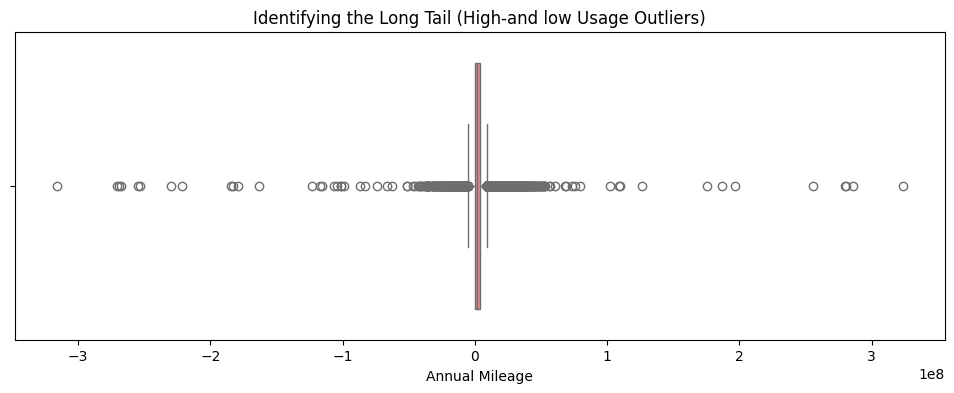

In [25]:
# Boxplot to visualize the Long Tail and outliers
plt.figure(figsize=(12, 4))
sns.boxplot(x=df_ml['mileage_diff'] * 365, color='lightcoral')
plt.title('Identifying the Long Tail (High-and low Usage Outliers)')
plt.xlabel('Annual Mileage')
plt.show()



**Fuel Type vs Mileage differnce bar chart:**

* Here, we examine how mileage discrepancies vary across different fuel types.

* The data is grouped by fuel type, and the average mileage difference is calculated for each category.

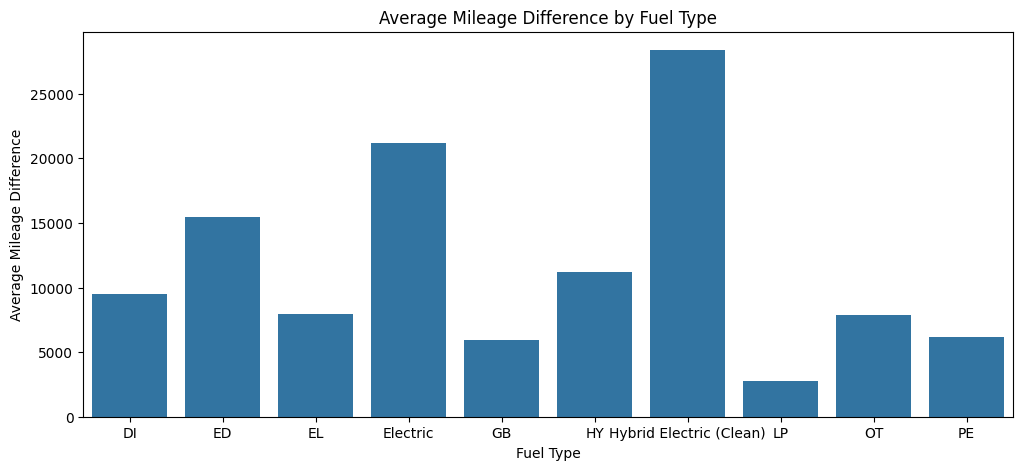

                 fuel_type  mileage_diff
0                       DI   9513.645347
1                       ED  15426.020833
2                       EL   7943.705645
3                 Electric  21175.066667
4                       GB   5944.937500
5                       HY  11220.991479
6  Hybrid Electric (Clean)  28375.661765
7                       LP   2769.533333
8                       OT   7859.169014
9                       PE   6168.431986


In [26]:
# Calculate average mileage_diff by fuel type
avg_mileage_fuel = df.groupby('fuel_type')['mileage_diff'].mean().reset_index()

# Plot
plt.figure(figsize=(12,5))
sns.barplot(data=avg_mileage_fuel, x='fuel_type', y='mileage_diff')
plt.title('Average Mileage Difference by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Mileage Difference')
plt.show()

print(avg_mileage_fuel)

**Car type vs Average annual Mileage differnce bar chart:**

* This section looks at how mileage changes vary across different vehicle brands.

* We first identify the top 15 most common brands in the dataset to keep the analysis focused and meaningful. Then, for each of these brands, we calculate the average mileage difference between tests.

/tmp/ipykernel_23351/396104275.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_mileage_brand, x='make', y='mileage_diff', palette='viridis')


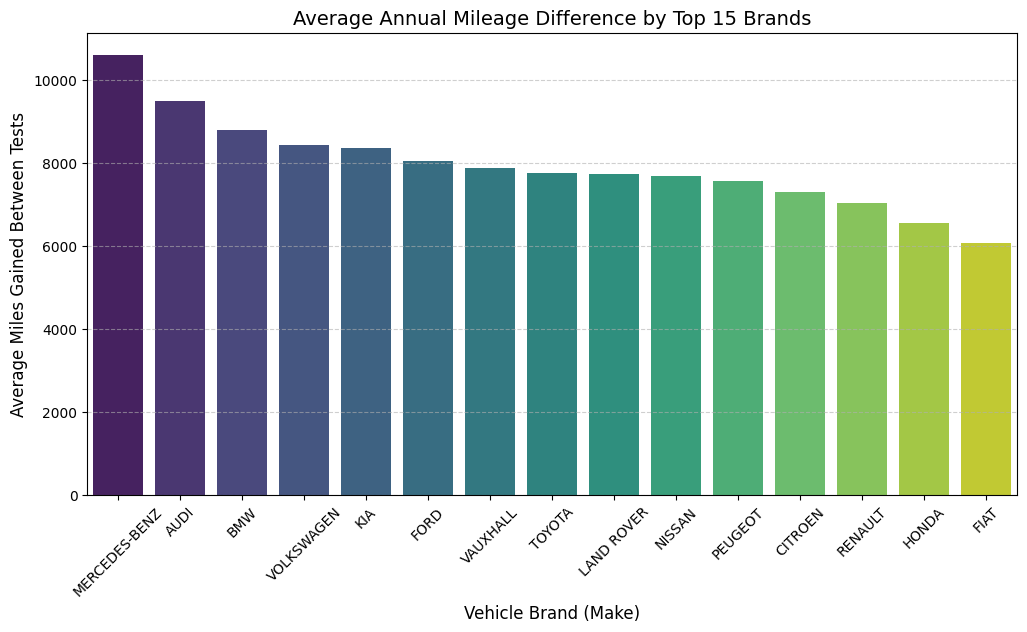

             make  mileage_diff
0   MERCEDES-BENZ  10609.762110
1            AUDI   9497.642983
2             BMW   8785.623462
3      VOLKSWAGEN   8434.159874
4             KIA   8364.835995
5            FORD   8039.516258
6        VAUXHALL   7868.190730
7          TOYOTA   7753.689365
8      LAND ROVER   7721.713374
9          NISSAN   7679.278088
10        PEUGEOT   7567.688472
11        CITROEN   7294.755390
12        RENAULT   7032.768669
13          HONDA   6545.971903
14           FIAT   6065.538784


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

#  Get the top 15 most frequent brands in your dataset
top_brands = df['make'].value_counts().nlargest(15).index

#  Filter and calculate the average mileage difference per brand
avg_mileage_brand = df[df['make'].isin(top_brands)].groupby('make')['mileage_diff'].mean().sort_values(ascending=False).reset_index()

#  Plotting
plt.figure(figsize=(12, 6))
sns.barplot(data=avg_mileage_brand, x='make', y='mileage_diff', palette='viridis')

plt.title('Average Annual Mileage Difference by Top 15 Brands', fontsize=14)
plt.xlabel('Vehicle Brand (Make)', fontsize=12)
plt.ylabel('Average Miles Gained Between Tests', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

# Print the values for your report
print(avg_mileage_brand)

**Distribution of Key Features:**

* In this section, we explore the distribution of two important variables: mileage difference and miles per day.

* To focus on realistic values and reduce the impact of extreme outliers, both variables are clipped to reasonable ranges:

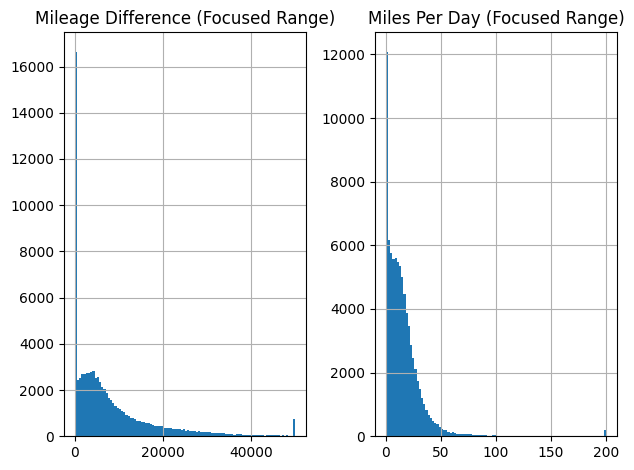

In [28]:
plt.figure()

# Mileage Difference (focus on realistic range)
plt.subplot(1, 2, 1)
df_ml['mileage_diff'].clip(0, 50000).hist(bins=100)
plt.title("Mileage Difference (Focused Range)")

# Miles Per Day
plt.subplot(1, 2, 2)
df_ml['miles_per_day'].clip(0, 200).hist(bins=100)
plt.title("Miles Per Day (Focused Range)")

plt.tight_layout()
plt.show()

if a car mileage at current mot is less than previous year mot we name it as negative mileage in our synthetic label coloumn which are obvious frauds later will use them in our testing dataset.

In [29]:
df_ml.loc[(df_ml['mileage_diff'] < 0) & (df_ml['synthetic_label'] == 'Normal'), 'synthetic_label'] = 'Negative_Mileage'

labeling the frauds as 1 and normal users as 0 such as negative annual mileage users and clocked commuters are actual fraud later we will seperate them from our dataset into testing dataset.

In [30]:
# 0 = The 'Honest' Baseline
# 1 = Any form of Anomaly (including Negative Mileage)
label_map = {
    'Normal': 0,
    'Clocked_Commuter': 1,
    'Rollback': 1,
    'Negative_Mileage': 1
}

df_ml['ground_truth'] = df_ml['synthetic_label'].map(label_map)

# Quick check to see counts
print(df_ml['synthetic_label'].value_counts())

synthetic_label
Normal              81065
Negative_Mileage      454
Clocked_Commuter      303
Name: count, dtype: int64


# Creating testing dataset
*  The dataset is divided into normal and anomalous records.
*  Anomalies are identified using non-“Normal” labels or negative
mileage differences.
* All anomalous records are moved to a separate forensic test dataset.
* All anomalous records are moved to a separate forensic test dataset.
* The remaining normal records are kept as the main dataset for training.
* This ensures the model learns only from clean data and is tested on fraudulent cases.

In [31]:
#  Identify all Anomalies
# 'synthetic_label' will be 'Normal' for honest cars, and something else for suspects
is_anomaly = (df_ml['synthetic_label'] != 'Normal') | (df_ml['mileage_diff'] < 0)

#  Extract the Forensic Test Set:The Fraudsters
df_forensic_test = df_ml[is_anomaly].copy()

#  Purify the main df_ml the Honest Cars
# We overwrite df_ml to contain only the 'Normal' records
df_ml = df_ml[~is_anomaly].copy()

print(f"--- Separation Complete ---")
print(f"Main dataset (df_ml) now has {len(df_ml)} clean records for training.")
print(f"Forensic dataset (df_forensic_test) has {len(df_forensic_test)} records for testing.")

--- Separation Complete ---
Main dataset (df_ml) now has 81065 clean records for training.
Forensic dataset (df_forensic_test) has 757 records for testing.


#Applying rules
Here we will use the DVSA 2013 statistical analysis rules to clean the dataset, our models need clean dataset for training.


*   Remove the rows where vehicles are driven more than 300 miles per day
*   Remove the rows where behaviour shift is less than 50% from previous year mileage till currunt year, if a driver drive the car less than 50% intensity from previous mot till current mot will be removed from the dataset.



In [32]:
import numpy as np

#  Define your Forensic Thresholds
behavioral_floor = 0.50  #  Must keep at least 80% of usual driving pace
max_daily_limit = 300    #  Must not exceed 300 miles per day

#  Apply the Three Forensic Rules to your dataset
# This creates the 'Gold Standard' version of df_ml
df_ml_clean = df_ml[
    #  The Physical Rule (No going backwards)
    (df_ml['mileage_diff'] >= 0) &

    #  The Behavioral Rule (The 80% Consistency Floor)
    (df_ml['usage_trend_shift'] >= behavioral_floor) &
    (df_ml['usage_trend_shift'] <= 1.20) & # Also cap it to avoid extreme jumps

    #  The Statistical Rule (The 300 miles/day Ceiling)
    (df_ml['miles_per_day'] <= max_daily_limit)
].copy()

#  Clean up any remaining calculation errors (NaN or Infinity)
df_ml_clean = df_ml_clean.replace([np.inf, -np.inf], np.nan).dropna(subset=['usage_trend_shift', 'mileage_diff'])

#  Results for your presentation notes
print(f"Data Purification Complete.")
print(f"Original records: {len(df_ml)}")
print(f"Purified records: {len(df_ml_clean)}")
print(f"Suspicious/Bad data removed: {len(df_ml) - len(df_ml_clean)}")

Data Purification Complete.
Original records: 81065
Purified records: 34188
Suspicious/Bad data removed: 46877


In [33]:
df_ml= df_ml_clean.copy()

* A random sample of normal records is selected from the dataset.
* These samples are labelled as normal (ground truth = 0).
* The sampled normal data is combined with the anomaly dataset to create a balanced forensic test set.
* The test set is shuffled to mix normal and anomalous records.
* The selected normal samples and all anomalies are removed from the main dataset.
* This ensures the training dataset contains only pure normal data for model learning.

In [34]:
df_normal_samples = df_ml[df_ml['synthetic_label'] == 'Normal'].sample(n=2000, random_state=42).copy()
df_normal_samples['ground_truth'] = 0  # 0 means Normal

#  Combine them to create your Forensic Test Set
df_forensic_test = pd.concat([df_forensic_test, df_normal_samples])
# Shuffle so the 0s and 1s are mixed
df_forensic_test = df_forensic_test.sample(frac=1, random_state=42).reset_index(drop=True)

#  REMOVE these specific normal samples and ALL anomalies from df_ml
# This ensures df_ml is now a 'Pure Normal' training set
df_ml = df_ml[df_ml['synthetic_label'] == 'Normal'].drop(df_normal_samples.index)

In [35]:
df_forensic_test.isnull().sum()

,0
test_id,0
vehicle_id,0
test_date,0
test_class_id,0
test_type,0
test_result,0
test_mileage,0
postcode_area,0
make,0
model,0


# Checking Testing Dataset:


In [36]:
df_forensic_test['synthetic_label'].value_counts()


,count
synthetic_label,
Normal,2000
Negative_Mileage,454
Clocked_Commuter,303


In [37]:
df_ml=df_ml[df_ml["mileage_diff"] > 0]

**Heat Map (Corelation graph)**
* Selects only the numerical features from the dataset and computes a correlation matrix to examine the relationships between variables.

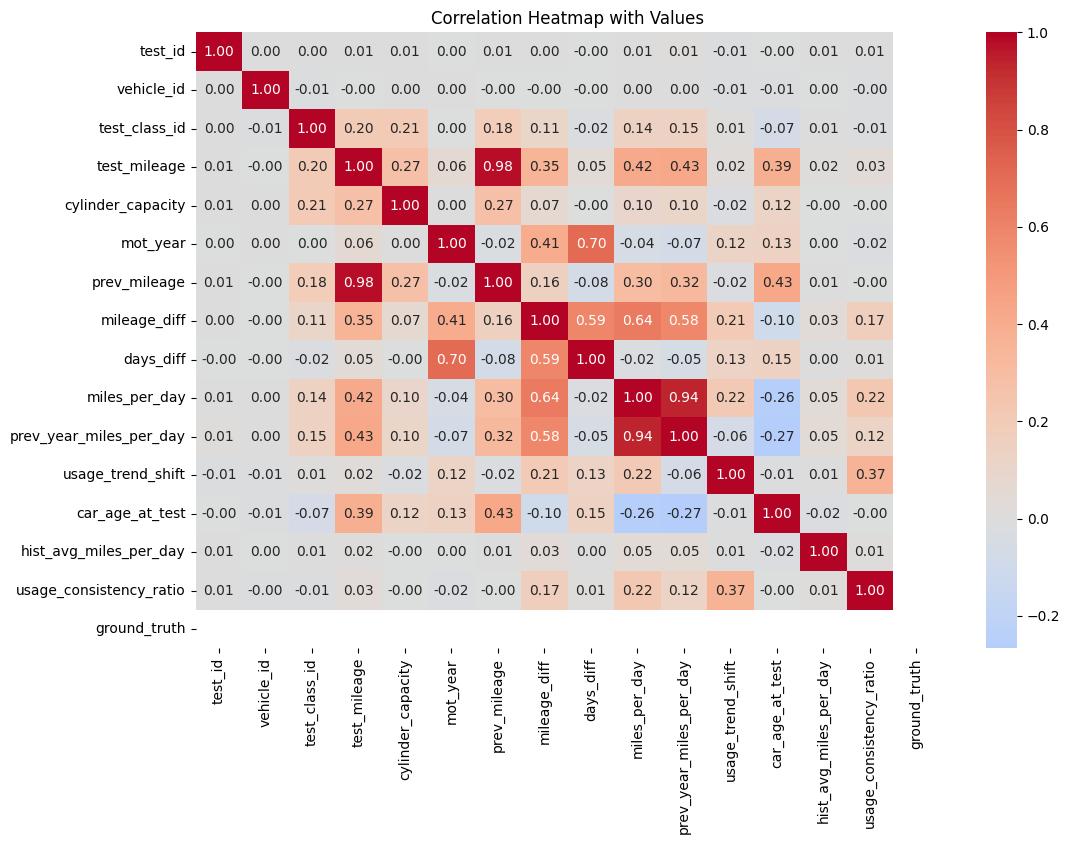

In [38]:

# Select numeric columns
df_numeric = df_ml.select_dtypes(include="number")

# Correlation matrix
corr_matrix = df_numeric.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap with Values")
plt.show()

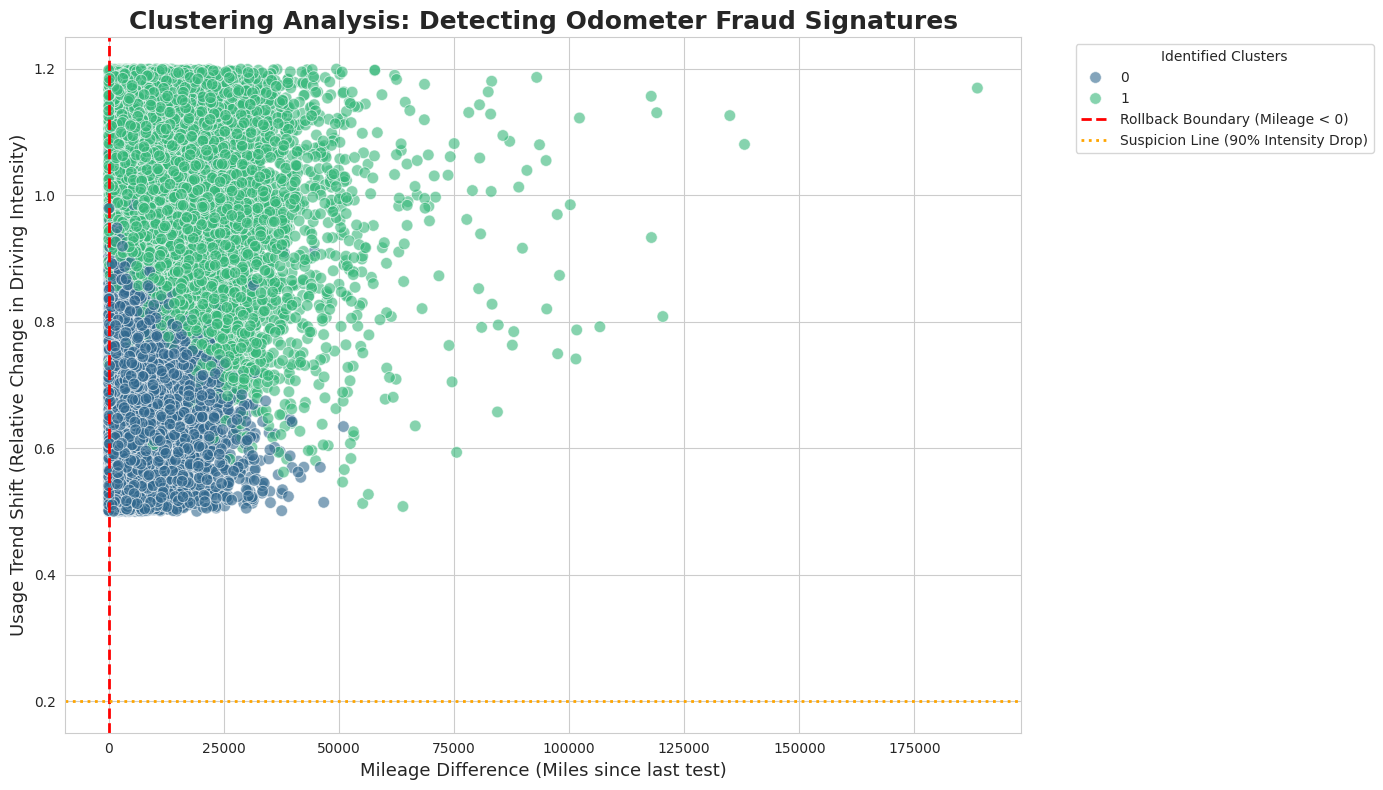

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

#  CLEANING & CAPPING (Fixing the ValueError)
df_viz = df_ml.copy()

# We replace Infinities with a fixed value (-10) so the Scaler can process them.
# This preserves the "signal" of a massive drop without breaking the math.
cols_to_fix = ['usage_trend_shift', 'usage_consistency_ratio']
df_viz[cols_to_fix] = df_viz[cols_to_fix].replace([np.inf, -np.inf], -10).fillna(0)

#  FEATURE SCALING
scaler = StandardScaler()
features_for_clustering = ['mileage_diff', 'usage_trend_shift', 'usage_consistency_ratio', 'car_age_at_test']
scaled_data = scaler.fit_transform(df_viz[features_for_clustering])

#  K-MEANS CLUSTERING (Pattern Discovery)
# We use 3 clusters: Normal, Obvious Fraud, and Sneaky Fraud
kmeans = KMeans(n_clusters=2, random_state=42)
df_viz['cluster'] = kmeans.fit_predict(scaled_data)

#  THE GRAPH (Visualizing the Fraud Signatures)
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Plotting Mileage Growth vs. Usage Shift
scatter = sns.scatterplot(
    data=df_viz,
    x='mileage_diff',
    y='usage_trend_shift',
    hue='cluster',
    palette='viridis',
    alpha=0.6,
    s=70
)

# Adding forensic reference lines
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Rollback Boundary (Mileage < 0)')
plt.axhline(y=0.2, color='orange', linestyle=':', linewidth=2, label='Suspicion Line (90% Intensity Drop)')

# Titles and Labels for the Meeting
plt.title('Clustering Analysis: Detecting Odometer Fraud Signatures', fontsize=18, fontweight='bold')
plt.xlabel('Mileage Difference (Miles since last test)', fontsize=13)
plt.ylabel('Usage Trend Shift (Relative Change in Driving Intensity)', fontsize=13)
plt.legend(title='Identified Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [40]:
df_ml.head()

,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,...,prev_test_date,days_diff,miles_per_day,prev_year_miles_per_day,usage_trend_shift,car_age_at_test,hist_avg_miles_per_day,usage_consistency_ratio,is_first_record,ground_truth
4,561151287,17374,2024-08-14,2,NT,P,32285.0,HU,SUZUKI,GSF1200,...,2021-07-19,1122.0,2.352941,2.948454,0.798026,25.872690,1.778444,1.323034,False,0
11,1548431635,174244,2020-10-13,4,NT,P,143875.0,CB,SAAB,9-3,...,2019-10-16,363.0,10.410468,11.775229,0.884099,13.338809,11.092849,0.938485,False,0
24,435521411,316955,2024-04-04,4,NT,P,143332.0,DN,VOLKSWAGEN,GOLF,...,2020-08-10,1333.0,11.820705,20.684524,0.571476,9.943874,14.587824,0.810313,False,0
29,445999409,370712,2024-07-23,4,NT,P,75297.0,SO,VAUXHALL,MERIVA,...,2021-08-20,1068.0,7.405431,10.972145,0.674930,13.815195,8.797946,0.841723,False,0
34,429468945,384010,2020-01-28,4,NT,P,83628.0,NW,RENAULT,MEGANE,...,2019-01-24,369.0,17.964770,19.991826,0.898606,11.991786,18.978298,0.946595,False,0


# Models Training:

# Isolation forest
* Applies the Isolation Forest algorithm to detect anomalies based on selected behavioural features that may indicate fraudulent activity.
* The model is trained on the dataset and used to predict anomalies, where each record is labelled as either normal (1) or suspicious (-1). In addition, an anomaly score is calculated for each record, where lower (more negative) values indicate a higher likelihood of being fraudulent.

In [41]:
from sklearn.ensemble import IsolationForest

#  Define the 'Behavioral' features
# These are the columns that 'reveal' the fraud
features = [
    'mileage_diff',
    'miles_per_day',
    'usage_trend_shift',
    'usage_consistency_ratio',
    'car_age_at_test'
]

#  Initializing the model

# contamination=0.04 means we expect roughly 4% of the data to be 'weird'
iso_model = IsolationForest(contamination=0.04,n_estimators=100, random_state=42)

#  Predict Anomalies
# -1 = Suspicious / 1 = Normal
df_ml['anomaly_flag'] = iso_model.fit_predict(df_ml[features])

#  Get the 'Suspicion Score'
df_ml['anomaly_score'] = iso_model.decision_function(df_ml[features])
print("Isolation forest Model training complete.")
print(f"Detected {len(df_ml[df_ml['anomaly_flag'] == -1])}  anomalies.")

Isolation forest Model training complete.
Detected 1288  anomalies.


# Local Outlier Factor
Applies the Local Outlier Factor (LOF) model to detect anomalies using selected features. The data is first cleaned and scaled to ensure accurate distance calculations. The model then identifies anomalous records by comparing each data point to its neighbours, labelling them as normal or suspicious.

In [42]:
import pandas as pd
import numpy as np
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

#  Define the features for the model
features_lof = ['mileage_diff', 'usage_trend_shift', 'usage_consistency_ratio', 'car_age_at_test']

# We cap Infinities at -10 to signal a 'massive usage drop' to the model
df_ml[features_lof] = df_ml[features_lof].replace([np.inf, -np.inf], -10).fillna(0)

#  FEATURE SCALING
scaler = StandardScaler()
scaled_lof_data = scaler.fit_transform(df_ml[features_lof])

#  INITIALIZE LOF
# n_neighbors=20: Compare each car to its 20 nearest behavioral neighbors
# contamination=0.02: We expect roughly 2% of the fleet to be anomalous
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.10)

#  RUNing MODEL-1 = Anomaly, 1 = Normal
df_ml['lof_anomaly_flag'] = lof.fit_predict(scaled_lof_data)

#  CALCULATE ANOMALY SCORES The more negative the score, the more 'outlier' the vehicle is
df_ml['lof_score'] = lof.negative_outlier_factor_

print("LOF Model training complete.")
print(f"Detected {len(df_ml[df_ml['lof_anomaly_flag'] == -1])} local anomalies.")

LOF Model training complete.
Detected 3219 local anomalies.


In [43]:
df_ml.head()

,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,...,usage_trend_shift,car_age_at_test,hist_avg_miles_per_day,usage_consistency_ratio,is_first_record,ground_truth,anomaly_flag,anomaly_score,lof_anomaly_flag,lof_score
4,561151287,17374,2024-08-14,2,NT,P,32285.0,HU,SUZUKI,GSF1200,...,0.798026,25.872690,1.778444,1.323034,False,0,-1,-0.011253,1,-1.095190
11,1548431635,174244,2020-10-13,4,NT,P,143875.0,CB,SAAB,9-3,...,0.884099,13.338809,11.092849,0.938485,False,0,1,0.177980,1,-0.987325
24,435521411,316955,2024-04-04,4,NT,P,143332.0,DN,VOLKSWAGEN,GOLF,...,0.571476,9.943874,14.587824,0.810313,False,0,1,0.112965,1,-1.076283
29,445999409,370712,2024-07-23,4,NT,P,75297.0,SO,VAUXHALL,MERIVA,...,0.674930,13.815195,8.797946,0.841723,False,0,1,0.146765,1,-1.071940
34,429468945,384010,2020-01-28,4,NT,P,83628.0,NW,RENAULT,MEGANE,...,0.898606,11.991786,18.978298,0.946595,False,0,1,0.180451,1,-1.021755


In [44]:
# #  Capture the records (exactly as you did for Isolation Forest)
# df_negatives_lof = df[df['mileage_diff'] < 0].copy()

# #  Apply the same "math fixes" to prevent crashes
# df_negatives_lof['usage_trend_shift'] = df_negatives_lof['usage_trend_shift'].replace([np.inf, -np.inf], -10).fillna(-10)
# df_negatives_lof['usage_consistency_ratio'] = df_negatives_lof['usage_consistency_ratio'].replace([np.inf, -np.inf], -10).fillna(-10)
# df_negatives_lof['hist_avg_miles_per_day'] = df_negatives_lof['hist_avg_miles_per_day'].fillna(0)

# #  Use the exact same features
# features_lof = [
#     'mileage_diff',
#     'miles_per_day',
#     'usage_trend_shift',
#     'usage_consistency_ratio',
#     'car_age_at_test'
# ]

# #  SCALE the data (MANDATORY for LOF)
# # LOF calculates distances, so features must be on the same scale
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# scaled_negatives = scaler.fit_transform(df_negatives_lof[features_lof])

# #  Predict anomalies using LOF
# # We use fit_predict to get the flags for this specific batch
# df_negatives_lof['lof_anomaly_flag'] = lof.fit_predict(scaled_negatives)

# # LOF uses "negative_outlier_factor_" as its score
# df_negatives_lof['lof_score'] = lof.negative_outlier_factor_

# #  Calculate Detection Rate
# lof_detection_rate = (df_negatives_lof['lof_anomaly_flag'] == -1).mean() * 100
# print(f"The LOF model identified {lof_detection_rate:.2f}% of negative mileage as fraud.")

# #  Look at the 'scores'
# print(df_negatives_lof[['vehicle_id', 'mileage_diff', 'lof_score', 'lof_anomaly_flag']].head(10))

In [45]:
df.head()

,test_id,vehicle_id,test_date,test_class_id,test_type,test_result,test_mileage,postcode_area,make,model,...,mileage_diff,prev_test_date,days_diff,miles_per_day,prev_year_miles_per_day,usage_trend_shift,car_age_at_test,hist_avg_miles_per_day,usage_consistency_ratio,is_first_record
1,956208647,17374,2019-07-23,2,NT,PRS,28077.0,HU,SUZUKI,GSF1200,...,205.0,2018-07-23,365.0,0.561644,NaN,NaN,20.810404,0.561644,1.000000,True
2,646909413,17374,2020-06-26,2,NT,P,28501.0,HU,SUZUKI,GSF1200,...,424.0,2019-07-23,339.0,1.250737,0.561644,2.226923,21.738535,0.906191,1.380214,False
3,1909903601,17374,2021-07-19,2,NT,P,29645.0,HU,SUZUKI,GSF1200,...,1144.0,2020-06-26,388.0,2.948454,1.250737,2.357372,22.800821,1.586945,1.857943,False
4,561151287,17374,2024-08-14,2,NT,P,32285.0,HU,SUZUKI,GSF1200,...,2640.0,2021-07-19,1122.0,2.352941,2.948454,0.798026,25.872690,1.778444,1.323034,False
10,1426417013,174244,2019-10-16,4,NT,P,140096.0,NN,SAAB,9-3,...,5134.0,2018-08-06,436.0,11.775229,NaN,NaN,12.344969,11.775229,1.000000,True


# One-Class SVM
* applies the One-Class SVM model to detect anomalies using selected features. The data is first cleaned by replacing infinite and missing values with a large negative value to make abnormal cases more distinguishable. Robust scaling is then applied to reduce the impact of extreme values.

In [46]:
#  Feature Selection
features_svm = ['mileage_diff', 'miles_per_day', 'usage_trend_shift', 'car_age_at_test']

#  Replacing Infinities with -100
# We use -100 because it pushes these 'impossible' records far away from the
# normal data (usually between 0 and 2), making them easy for SVM to flag.
df_ml[features_svm] = df_ml[features_svm].replace([np.inf, -np.inf], -100).fillna(-100)

#  Robust Scaling (Now it will work!)
from sklearn.preprocessing import RobustScaler
scaler_svm = RobustScaler()
scaled_svm_data = scaler_svm.fit_transform(df_ml[features_svm])

#  Initialize and Run One-Class SVM
from sklearn.svm import OneClassSVM

svm_model = OneClassSVM(kernel='rbf', nu=0.03, gamma='scale')

df_ml['svm_flag'] = svm_model.fit_predict(scaled_svm_data)
print("one class svm  Model training complete.")
print(f"Detected {len(df_ml[df_ml['svm_flag'] == -1])} local anomalies.")

one class svm  Model training complete.
Detected 964 local anomalies.


In [47]:
# Create the High Confidence flag using your ACTUAL column names
# Replace 'anomaly_flag' if your print(df_ml.columns) showed something different
df_ml['high_confidence_fraud'] = ((df_ml['anomaly_flag'] == -1) & (df_ml['svm_flag'] == -1))

# Summary Statistics
total_iso = (df_ml['anomaly_flag'] == -1).sum()
total_svm = (df_ml['svm_flag'] == -1).sum()
both_agree = df_ml['high_confidence_fraud'].sum()

print(f"Isolation Forest (Original) Flags: {total_iso}")
print(f"One-Class SVM (New) Flags: {total_svm}")
print(f"--- BOTH MODELS AGREED ON: {both_agree} Vehicles ---")

Isolation Forest (Original) Flags: 1288
One-Class SVM (New) Flags: 964
--- BOTH MODELS AGREED ON: 649 Vehicles ---


In [48]:
#  Defining the features
features_iso = [
    'mileage_diff',
    'miles_per_day',
    'usage_trend_shift',
    'usage_consistency_ratio',
    'car_age_at_test'
]


df_forensic_test[features_iso] = df_forensic_test[features_iso].replace([np.inf, -np.inf], -100).fillna(-100)

#  Run Predictions on your recently separated Testing Dataset
df_forensic_test['iso_pred'] = iso_model.predict(df_forensic_test[features_iso])

#  Get the Anomaly Score
df_forensic_test['iso_score'] = iso_model.decision_function(df_forensic_test[features_iso])

#  Generate the Results Report
print("--- ISOLATION FOREST: TEST DATASET RESULTS ---")
total_rate = (df_forensic_test['iso_pred'] == -1).mean() * 100
print(f"Overall Detection Rate: {total_rate:.2f}%")

# checking results
persona_iso = df_forensic_test.groupby('synthetic_label')['iso_pred'].apply(lambda x: (x == -1).mean() * 100)

print("\n--- Detection Accuracy by Fraud Type ---")
print(persona_iso)

--- ISOLATION FOREST: TEST DATASET RESULTS ---
Overall Detection Rate: 23.03%

--- Detection Accuracy by Fraud Type ---
synthetic_label
Clocked_Commuter     32.013201
Negative_Mileage    100.000000
Normal                4.200000
Name: iso_pred, dtype: float64


In [49]:
#  Define the features (Must be the exact same as your training features)
features_svm = [
    'mileage_diff',
    'miles_per_day',
    'usage_trend_shift',

    'car_age_at_test'
]

# SVMs cannot handle 'Infinity'. We cap them at -100 to show a massive usage drop.
df_forensic_test[features_svm] = df_forensic_test[features_svm].replace([np.inf, -np.inf], -100).fillna(-100)

#  Scaling the Testing Data
scaled_forensic = scaler_svm.transform(df_forensic_test[features_svm])

#  Runing Predictions on the Testing Dataset
# -1 = Detected as Anomaly, 1 = Normal
df_forensic_test['svm_pred'] = svm_model.predict(scaled_forensic)

# 5. Get Decision Scores Distance from the Normal boundary
df_forensic_test['svm_score'] = svm_model.decision_function(scaled_forensic)

#  Generate the Performance Report
print("--- ONE-CLASS SVM: TEST DATASET RESULTS ---")
svm_total = (df_forensic_test['svm_pred'] == -1).mean() * 100
print(f"Overall Detection Rate: {svm_total:.2f}%")

# testing on testing set
persona_svm = df_forensic_test.groupby('synthetic_label')['svm_pred'].apply(lambda x: (x == -1).mean() * 100)

print("\n--- Detection Accuracy by Fraud Type ---")
print(persona_svm)

--- ONE-CLASS SVM: TEST DATASET RESULTS ---
Overall Detection Rate: 26.95%

--- Detection Accuracy by Fraud Type ---
synthetic_label
Clocked_Commuter     75.247525
Negative_Mileage    100.000000
Normal                3.050000
Name: svm_pred, dtype: float64


A **Venn diagram** is used to show:

* Data points flagged only by Isolation Forest
* Data points flagged only by One-Class SVM
* Data points flagged by both models (high-confidence anomalies)

The overlapping region represents cases where both models agree, which can be considered more reliable or higher-risk anomalies.

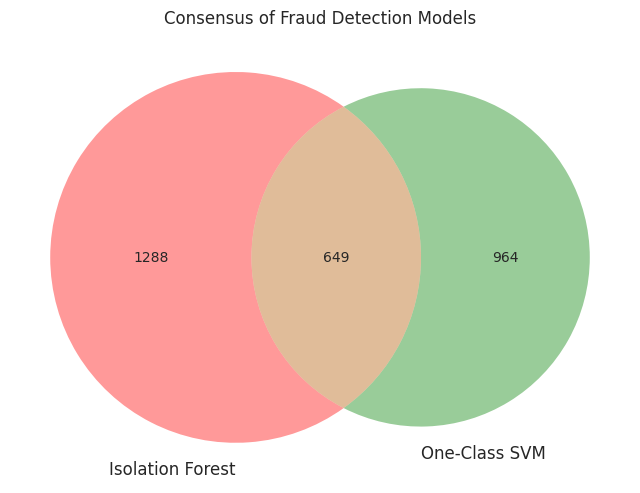

In [50]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Creating a Venn Diagram of the Flags
plt.figure(figsize=(8, 8))
venn = venn2(subsets = (
    len(df_ml[df_ml['anomaly_flag'] == -1]), # Isolation Forest anomalies
    len(df_ml[df_ml['svm_flag'] == -1]),     # SVM anomalies
    len(df_ml[df_ml['high_confidence_fraud'] == True]) # Both
), set_labels = ('Isolation Forest', 'One-Class SVM'))

plt.title("Consensus of Fraud Detection Models")
plt.show()

# Elliptic Envelope
* Applies the Elliptic Envelope model to detect anomalies based on statistical distribution. The data is first cleaned and standardised to ensure consistency across features. The model then fits an elliptical boundary around the normal data points and identifies those lying outside this boundary as anomalies.

In [51]:
from sklearn.covariance import EllipticEnvelope
from sklearn.preprocessing import StandardScaler

#  Initialize the Standard Scaler
std_scaler = StandardScaler()

#  Fit and Transform the ML features
df_ml[features_svm] = df_ml[features_svm].replace([np.inf, -np.inf], -100).fillna(-100)
scaled_std_data = std_scaler.fit_transform(df_ml[features_svm])

# We keep contamination at 0.03 for a fair comparison
ee_std_model = EllipticEnvelope(contamination=0.03, random_state=42)

#  fiting the model
df_ml['ee_std_flag'] = ee_std_model.fit_predict(scaled_std_data)

#  Get the Decision Score Statistical Distance
df_ml['ee_std_score'] = ee_std_model.decision_function(scaled_std_data)

print(f"Standard-Scaled EE flagged: {len(df_ml[df_ml['ee_std_flag'] == -1])} vehicles")

Standard-Scaled EE flagged: 966 vehicles


#Testing
* Testing our models on the validation dataset. which we have created by using the poisend data and getting negative mileage and normal data from the dataset.

In [52]:

# We use the same list of features you defined in your code
features_if = ['mileage_diff', 'miles_per_day', 'usage_trend_shift', 'usage_consistency_ratio', 'car_age_at_test']

# Handling infinities in the forensic set just like we did for training
X_forensic_if = df_forensic_test[features_if].replace([np.inf, -np.inf], -100).fillna(-100)

#  Prediction on Forensic Data
df_forensic_test['if_prediction_raw'] = iso_model.predict(X_forensic_if)

#  Map to match your 'ground_truth' (0=Normal, 1=Anomaly)
# Isolation Forest outputs -1 for anomaly, 1 for normal
df_forensic_test['if_flag'] = df_forensic_test['if_prediction_raw'].map({1: 0, -1: 1})

print("Isolation Forest Testing Complete.")

Isolation Forest Testing Complete.


In [53]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare Features for SVM
features_svm = ['mileage_diff', 'miles_per_day', 'usage_trend_shift', 'car_age_at_test']
X_forensic_svm = df_forensic_test[features_svm].replace([np.inf, -np.inf], -100).fillna(-100)

#  Scale the Forensic data using the PREVIOUSLY FIT scaler we need it cause we used it while modeling
scaled_forensic_svm = scaler_svm.transform(X_forensic_svm)

# Predict on Forensic Data
df_forensic_test['svm_prediction_raw'] = svm_model.predict(scaled_forensic_svm)

# Map to match your 'ground_truth' (0=Normal, 1=Anomaly)
df_forensic_test['svm_flag'] = df_forensic_test['svm_prediction_raw'].map({1: 0, -1: 1})

print("One-Class SVM Testing Complete.")

One-Class SVM Testing Complete.


In [54]:
# Defining featurs
features_lof = ['mileage_diff',
    'usage_trend_shift',
    'usage_consistency_ratio',
    'car_age_at_test']

X_forensic_lof = df_forensic_test[features_lof].replace([np.inf, -np.inf], -10).fillna(0)

# Scaling because we used scaler while modeling
X_forensic_lof_scaled = scaler.transform(X_forensic_lof)

#  Prediction

df_forensic_test['lof_prediction_raw'] = lof.fit_predict(X_forensic_lof_scaled)

#  Map results to match Ground Truth
# Ground Truth uses: 1 (Anomaly), 0 (Normal)
df_forensic_test['lof_flag'] = df_forensic_test['lof_prediction_raw'].map({1: 0, -1: 1})




In [55]:
#  Use the same features defined in your EE training cell

X_forensic_ee = df_forensic_test[features_svm].replace([np.inf, -np.inf], -100).fillna(-100)

#  Transform the forensic data using the Standard Scaler

X_forensic_ee_scaled = std_scaler.transform(X_forensic_ee)

#  Predict on Forensic Data

df_forensic_test['ee_prediction_raw'] = ee_std_model.predict(X_forensic_ee_scaled)

#  Map to match Ground Truth (1 = Normal, -1 = Anomaly -> 0 = Normal, 1 = Anomaly)
df_forensic_test['ee_flag'] = df_forensic_test['ee_prediction_raw'].map({1: 0, -1: 1})



# Model Evaluation and Visualization

* we calculate key performance metrics to evaluate how well each anomaly detection model performs.

* We define a function that computes: Accuracy, Precision, Recall, F1-Score
* We then apply this function to each model:Isolation Forest,One-Class SVM, Local Outlier Factor (LOF), Elliptic Envelope

In [56]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Function to display the results
def get_model_stats(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"--- {model_name} Statistics ---")
    print(f"Accuracy:  {acc:.2%}")
    print(f"Precision: {prec:.2%}") # How many flags were actually fraud
    print(f"Recall:    {rec:.2%}")    # How many of the anomalies model actually caught
    print(f"F1-Score:  {f1:.2%}")     # The balance between Precision and Recall
    print("-" * 30)

# Run it for your results
get_model_stats(df_forensic_test['ground_truth'], df_forensic_test['if_flag'], "Isolation Forest")
get_model_stats(df_forensic_test['ground_truth'], df_forensic_test['svm_flag'], "One-Class SVM")
get_model_stats(df_forensic_test['ground_truth'], df_forensic_test['lof_flag'], "Local Outlier Factor")
get_model_stats(df_forensic_test['ground_truth'], df_forensic_test['ee_flag'], "Elliptic Envelope")

--- Isolation Forest Statistics ---
Accuracy:  89.48%
Precision: 86.77%
Recall:    72.79%
F1-Score:  79.17%
------------------------------
--- One-Class SVM Statistics ---
Accuracy:  95.07%
Precision: 91.79%
Recall:    90.09%
F1-Score:  90.93%
------------------------------
--- Local Outlier Factor Statistics ---
Accuracy:  77.11%
Precision: 72.83%
Recall:    26.55%
F1-Score:  38.92%
------------------------------
--- Elliptic Envelope Statistics ---
Accuracy:  80.49%
Precision: 82.30%
Recall:    36.86%
F1-Score:  50.91%
------------------------------


**Confusion matrix:**
* we evaluate the performance of our anomaly detection models by comparing their predictions with the ground truth labels.
* creating a **confusion matrix** to show how many predictions were correct or incorrect

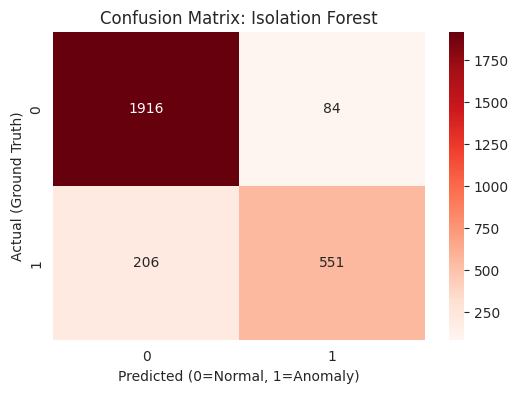


--- Isolation Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.96      0.93      2000
           1       0.87      0.73      0.79       757

    accuracy                           0.89      2757
   macro avg       0.89      0.84      0.86      2757
weighted avg       0.89      0.89      0.89      2757



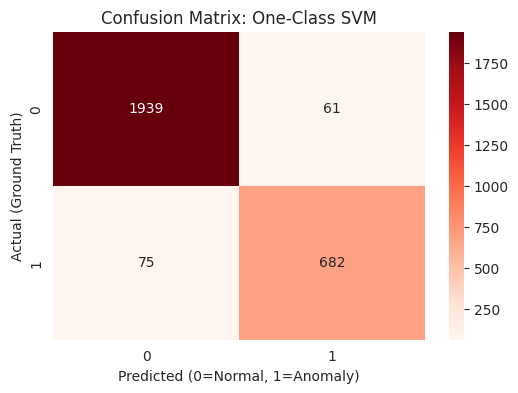


--- One-Class SVM Classification Report ---
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      2000
           1       0.92      0.90      0.91       757

    accuracy                           0.95      2757
   macro avg       0.94      0.94      0.94      2757
weighted avg       0.95      0.95      0.95      2757



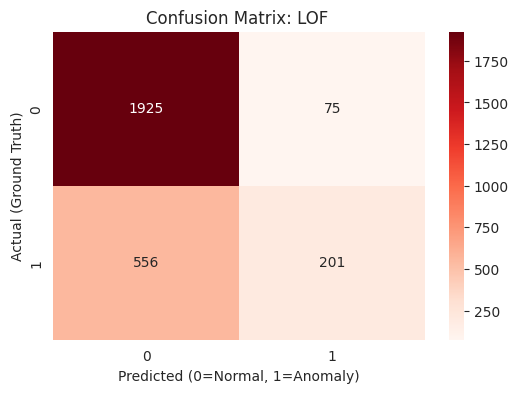


--- LOF  Classification Report ---
              precision    recall  f1-score   support

           0       0.78      0.96      0.86      2000
           1       0.73      0.27      0.39       757

    accuracy                           0.77      2757
   macro avg       0.75      0.61      0.62      2757
weighted avg       0.76      0.77      0.73      2757



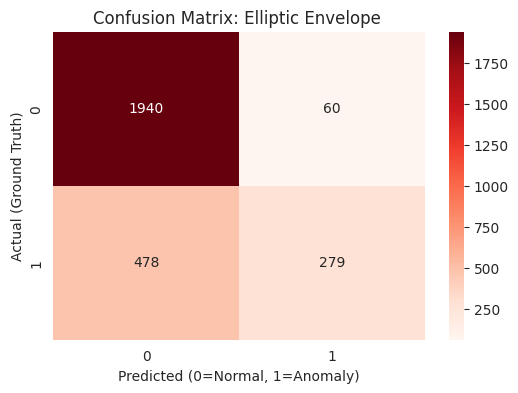


--- Elliptic Envelope  Classification Report ---
              precision    recall  f1-score   support

           0       0.80      0.97      0.88      2000
           1       0.82      0.37      0.51       757

    accuracy                           0.80      2757
   macro avg       0.81      0.67      0.69      2757
weighted avg       0.81      0.80      0.78      2757



In [57]:
def plot_results(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted (0=Normal, 1=Anomaly)')
    plt.ylabel('Actual (Ground Truth)')
    plt.show()

    print(f"\n--- {model_name} Classification Report ---")
    print(classification_report(y_true, y_pred))

# Run for Isolation Forest
plot_results(df_forensic_test['ground_truth'], df_forensic_test['if_flag'], "Isolation Forest")

# Run for One-Class SVM
plot_results(df_forensic_test['ground_truth'], df_forensic_test['svm_flag'], "One-Class SVM")
plot_results(df_forensic_test['ground_truth'], df_forensic_test['lof_flag'], "LOF ")
plot_results(df_forensic_test['ground_truth'], df_forensic_test['ee_flag'], "Elliptic Envelope ")

**Comparing Model Performance:**

* To get a clearer picture of how each model performs, we bring all evaluation metrics together into a single visualization.

* This function calculates accuracy, precision, recall, and F1-score for each model using the test dataset. The results are then organized into a table and displayed as a bar chart

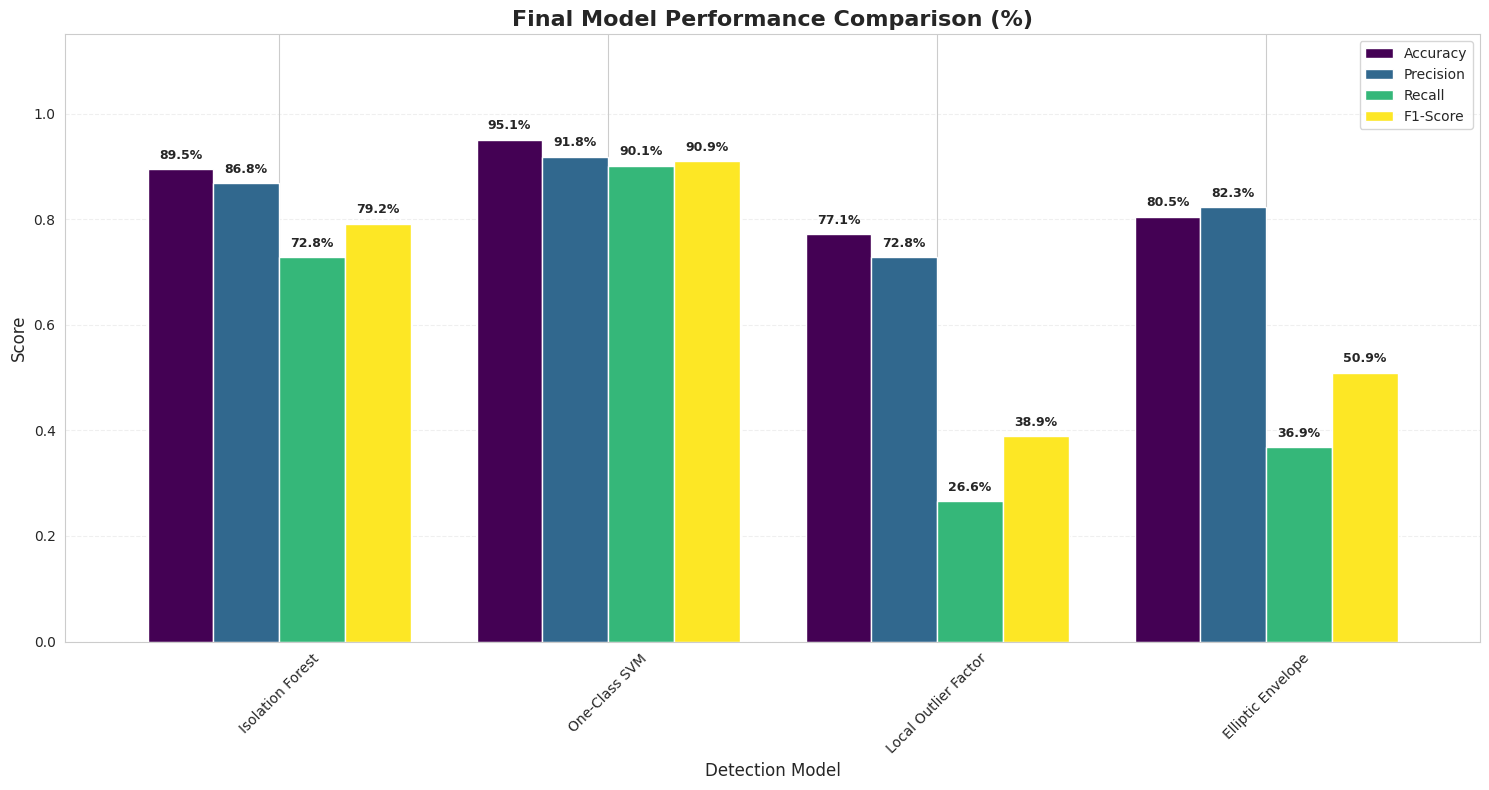

In [58]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def plot_final_metrics_with_labels(test_df):
    #  Map models to their prediction columns
    model_map = {
        'Isolation Forest': 'if_flag',
        'One-Class SVM': 'svm_flag',
        'Local Outlier Factor': 'lof_flag',
        'Elliptic Envelope': 'ee_flag'
    }

    y_true = test_df['ground_truth']
    results = []

    #  Calculate the Report
    for name, col in model_map.items():
        y_pred = test_df[col]
        results.append({
            'Model': name,
            'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred),
            'Recall': recall_score(y_true, y_pred),
            'F1-Score': f1_score(y_true, y_pred)
        })

    #  Prepare DataFrame
    res_df = pd.DataFrame(results).set_index('Model')

    #  Create the Plot
    ax = res_df.plot(kind='bar', figsize=(15, 8), width=0.8, colormap='viridis')

    plt.title('Final Model Performance Comparison (%)', fontsize=16, fontweight='bold')
    plt.ylabel('Score', fontsize=12)
    plt.xlabel('Detection Model', fontsize=12)
    plt.ylim(0, 1.15) # Extra space for labels
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend(loc='upper right', bbox_to_anchor=(1, 1))

    #  Add Percentage Labels on top of each bar
    for p in ax.patches:
        height = p.get_height()
        if height > 0: # Only label bars that have a value
            ax.annotate(f'{height:.1%}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center',
                        xytext=(0, 10),
                        textcoords='offset points',
                        fontsize=9,
                        fontweight='bold')

    plt.tight_layout()
    plt.show()

# Run the visualization
plot_final_metrics_with_labels(df_forensic_test)

**Visualising Model Decisions:**

* In this section, we explore how each model classifies data points by plotting them in a two-dimensional space.
* The position is based on mileage difference and usage trend shift
* The colour of the data point indicates whether the model flagged it as normal or anomalous

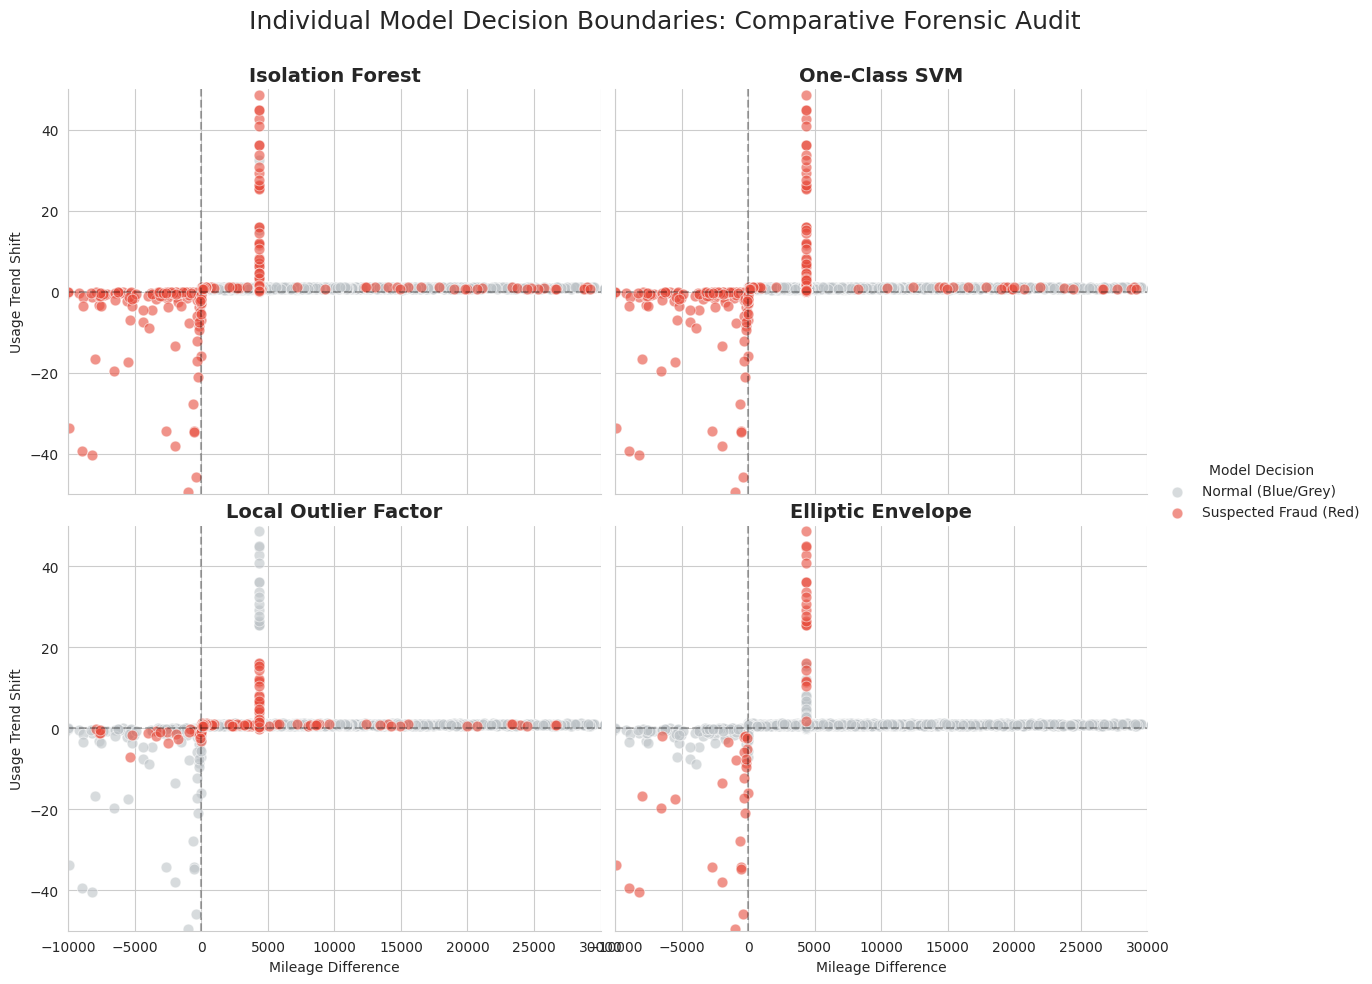

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Melt the data to a "Long Format" for FacetGrid
# We want a single column for the model name and a single column for the flag
model_cols = {
    'if_flag': 'Isolation Forest',
    'svm_flag': 'One-Class SVM',
    'lof_flag': 'Local Outlier Factor',
    'ee_flag': 'Elliptic Envelope'
}

# Create a temporary dataframe for plotting
plot_data = []
for col, name in model_cols.items():
    temp = df_forensic_test[['mileage_diff', 'usage_trend_shift', 'synthetic_label', col]].copy()
    temp['Model_Name'] = name
    temp.columns = ['mileage_diff', 'usage_trend_shift', 'synthetic_label', 'is_anomaly', 'Model_Name']
    plot_data.append(temp)

df_plot = pd.concat(plot_data)

#  Create the FacetGrid
g = sns.FacetGrid(df_plot, col="Model_Name", col_wrap=2, height=5, aspect=1.2, hue="is_anomaly", palette={0: '#bdc3c7', 1: '#e74c3c'})

#  Map the scatterplot to each grid
g.map(sns.scatterplot, "mileage_diff", "usage_trend_shift", alpha=0.6, s=60, edgecolor='w')

#  Adding visual boundaries for context
for ax in g.axes.flat:
    ax.axvline(x=0, color='black', linestyle='--', alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
    ax.set_xlim(-10000, 30000)
    ax.set_ylim(-50, 50)

#  adding titles lengends
g.add_legend(title="Model Decision", labels=['Normal (Blue/Grey)', 'Suspected Fraud (Red)'])
g.set_titles("{col_name}", size=14, fontweight='bold')
g.set_axis_labels("Mileage Difference", "Usage Trend Shift")

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Individual Model Decision Boundaries: Comparative Forensic Audit', fontsize=18)

plt.show()

In [60]:
import joblib
#  Saving the Isolation Forest
joblib.dump(iso_model, 'isolation_forest_mot_model.pkl')

#  Saving the One-Class SVM
joblib.dump(svm_model, 'svm_mot_model.pkl')

#  Saving the Elliptic Envelope
joblib.dump(ee_std_model, 'Elliptic Envelope.pkl')

#  Saving the Local Outlier Factor
joblib.dump(lof, 'LOF.pkl')

print("All models and scalers saved successfully!")

All models and scalers saved successfully!


# Conclusion
The evaluation demonstrates that One-Class SVM is the superior model for this forensic task, achieving the highest F1-Score (90.93%) and Recall (90.09%). This indicates a high sensitivity to the subtle "Clocked Commuter" patterns injected into the dataset.

Key Findings:

Winner: One-Class SVM provided the best balance, successfully catching the vast majority of frauds while maintaining a high Precision (91.79%), ensuring minimal false accusations against honest drivers.

Strong Runner-Up: Isolation Forest performed well but struggled more with the overlap between normal behavior and subtle anomalies, as seen in its lower recall (72.379%).

Underperformers: Both Local Outlier Factor and Elliptic Envelope showed poor recall (<40%). This suggests that the fraud patterns are not purely statistical outliers or density-based clusters, but rather complex boundary violations that require the high-dimensional mapping capabilities of SVM